In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
import joblib

# === 1. Load Dataset ===
df = pd.read_csv('dataset_textile.csv')
print(f" Loaded dataset with shape: {df.shape}")

# === 2. Feature Engineering ===
df['brand_tier'] = df['Brand'].str.extract(r'\((.*?)\)').fillna('Unknown')
df['product_category'] = df['Product_type'].str.split().str[0].fillna('Unknown')

# === 3. Label Encoding ===
cat_cols = ['fabric', 'brand_tier', 'product_category', 'Size']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# === 4. Feature & Target Columns ===
feature_cols = [f'{col}_encoded' for col in cat_cols]
X = df[feature_cols]
y_class = (df['selling_price'] > df['selling_price'].median()).astype(int)
y_price = df['selling_price']
y_costs = df[['fabric_raw_cost', 'manufacturing', 'transportation', 'brand_value', 'retailer_margin', 'tax']].clip(lower=0)

# === Optional: Log-transform target costs ===
y_costs_log = np.log1p(y_costs)

# === 5. Train/Test Split ===
X_train, X_test, y_class_train, y_class_test = train_test_split(X, y_class, stratify=y_class, test_size=0.2, random_state=42)
_, _, y_price_train, y_price_test = train_test_split(X, y_price, stratify=y_class, test_size=0.2, random_state=42)
_, _, y_cost_train_log, y_cost_test_log = train_test_split(X, y_costs_log, stratify=y_class, test_size=0.2, random_state=42)

# === 6. Train XGBoost Models ===
clf = XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
                    random_state=42, eval_metric='logloss', use_label_encoder=False)
reg = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=42)
reg_multi = MultiOutputRegressor(XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42))

print(" Training classifier...")
clf.fit(X_train, y_class_train)

print("Training regressor...")
reg.fit(X_train, y_price_train)

print(" Training multi-output regressor...")
reg_multi.fit(X_train, y_cost_train_log)

# === 7. Evaluate Classifier ===
y_pred_class = clf.predict(X_test)
print("\n Classification Report:")
print(classification_report(y_class_test, y_pred_class))
print("\n Confusion Matrix:")
print(confusion_matrix(y_class_test, y_pred_class))
accuracy = accuracy_score(y_class_test, y_pred_class)
print(f"\n Accuracy: {accuracy:.4f}")

# === 8. Train GA-Optimized RandomForest ===
best_params = {
    'n_estimators': 150,
    'max_depth': 8,
    'min_samples_split': 4
}  # Replace with actual GA output

print("\n Training final cost model with GA-optimized RandomForest...")
rf_ga = RandomForestRegressor(**best_params, random_state=42)
reg_multi_ga = MultiOutputRegressor(rf_ga)
reg_multi_ga.fit(X_train, y_cost_train_log)

# === 9. Save All Artifacts ===
artifacts = {
    'classifier': clf,
    'regressor': reg,
    'multi_regressor': reg_multi,
    'multi_regressor_ga': reg_multi_ga,
    'encoders': label_encoders,
    'fabric_types': label_encoders['fabric'].classes_.tolist(),
    'product_categories': label_encoders['product_category'].classes_.tolist(),
    'sizes': label_encoders['Size'].classes_.tolist(),
    'brand_tiers': label_encoders['brand_tier'].classes_.tolist(),
    'costs_log_scaled': True
}

joblib.dump(artifacts, 'xgb_rf_ga_models.pkl')
print("\n All models and encoders saved to 'xgb_rf_ga_models.pkl'")


 Loaded dataset with shape: (153000, 12)
 Training classifier...


c:\Users\vardh\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:44:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training regressor...
 Training multi-output regressor...

 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     15300
           1       0.95      0.95      0.95     15300

    accuracy                           0.95     30600
   macro avg       0.95      0.95      0.95     30600
weighted avg       0.95      0.95      0.95     30600


 Confusion Matrix:
[[14474   826]
 [  837 14463]]

 Accuracy: 0.9457

 Training final cost model with GA-optimized RandomForest...

 All models and encoders saved to 'xgb_rf_ga_models.pkl'


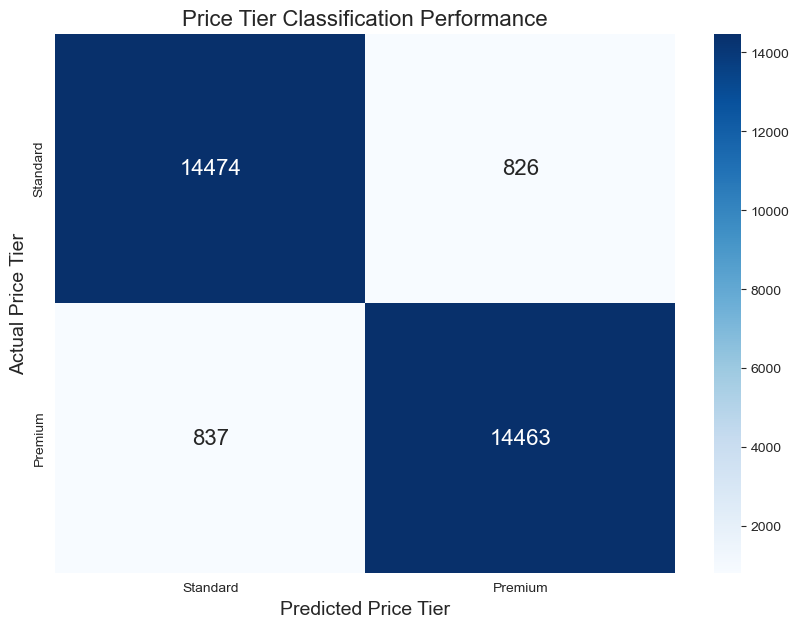

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(10,7))
cm = confusion_matrix(y_class_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            annot_kws={"size": 16},
            xticklabels=['Standard', 'Premium'],
            yticklabels=['Standard', 'Premium'])
plt.xlabel('Predicted Price Tier', fontsize=14)
plt.ylabel('Actual Price Tier', fontsize=14)
plt.title('Price Tier Classification Performance', fontsize=16)
plt.show()


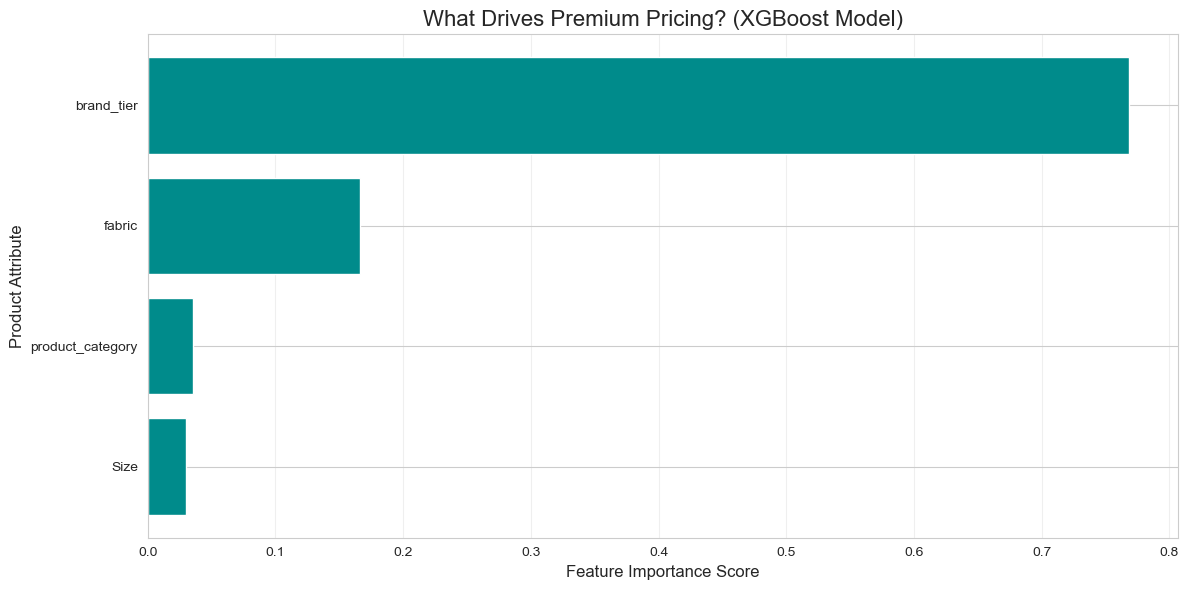

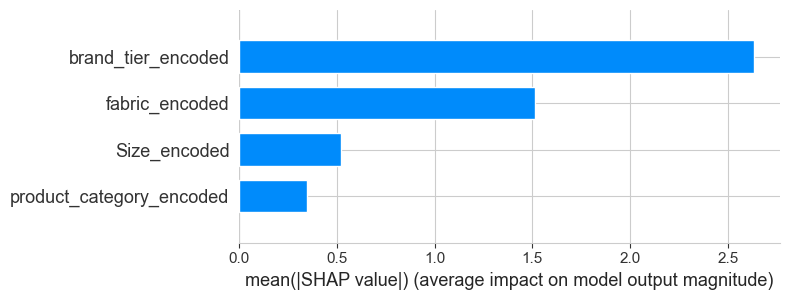

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import shap

# === Define your categorical columns and get encoded feature columns ===
cat_cols = ['fabric', 'brand_tier', 'product_category', 'Size']
feature_cols = [f'{col}_encoded' for col in cat_cols]

# === Define X ===
X = df[feature_cols]

# === Get feature importances from the model ===
try:
    final_estimator = best_model.named_steps[list(best_model.named_steps)[-1]]
    if hasattr(final_estimator, 'feature_importances_'):
        importances = final_estimator.feature_importances_
        source = "GA-Optimized Model"
    else:
        importances = clf.feature_importances_
        source = "XGBoost Model"
except NameError:
    importances = clf.feature_importances_
    source = "XGBoost Model"

# === Clean feature names and map importance ===
feature_names = [col.replace('_encoded', '') for col in X.columns]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).groupby('Feature', as_index=False).sum().sort_values('Importance', ascending=True)

# === Plotting ===
plt.figure(figsize=(12, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='darkcyan')
plt.title(f'What Drives Premium Pricing? ({source})', fontsize=16)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Product Attribute', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



# SHAP Explainer
explainer = shap.Explainer(clf)  # clf is your trained model
shap_values = explainer(X)

# Summary plot
shap.summary_plot(shap_values, X, plot_type='bar')

C:\Users\vardh\AppData\Local\Temp\ipykernel_4352\808404608.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fabric', y='selling_price', data=df, palette='viridis')


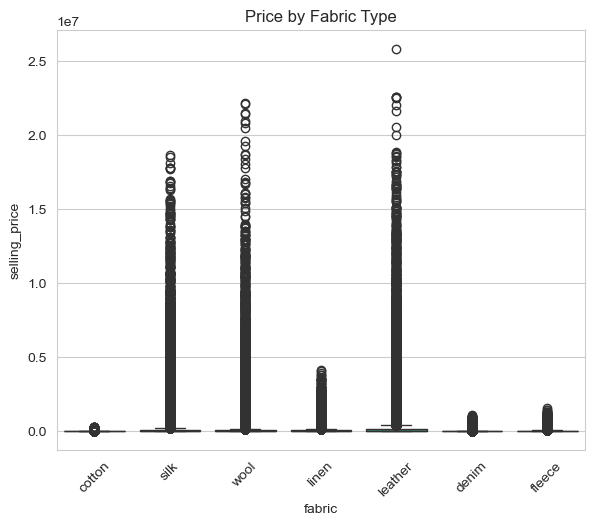

In [27]:
# Price by Fabric Type
sns.set_style("whitegrid")
plt.figure(figsize=(15,12))
plt.subplot(2,2,2)
sns.boxplot(x='fabric', y='selling_price', data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title("Price by Fabric Type")
plt.show()

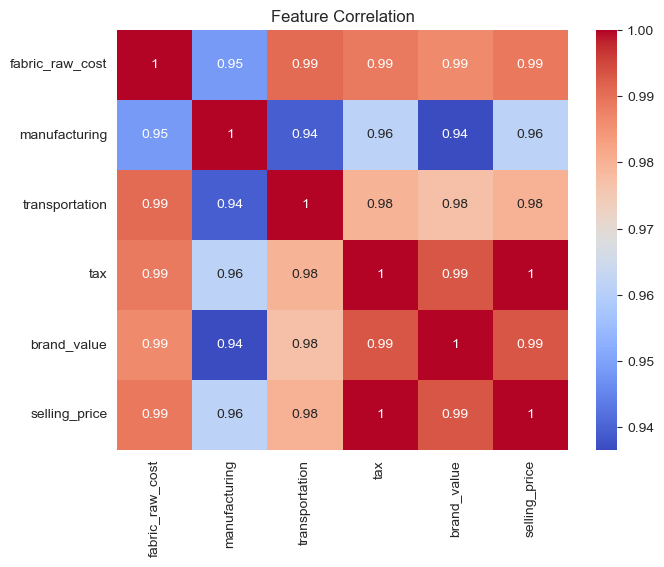

In [28]:
# Feature Correlation
plt.figure(figsize=(16,12))
plt.subplot(2,2,3)
numeric_cols = ['fabric_raw_cost','manufacturing','transportation','tax','brand_value','selling_price']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


Global Feature Importance Plot:


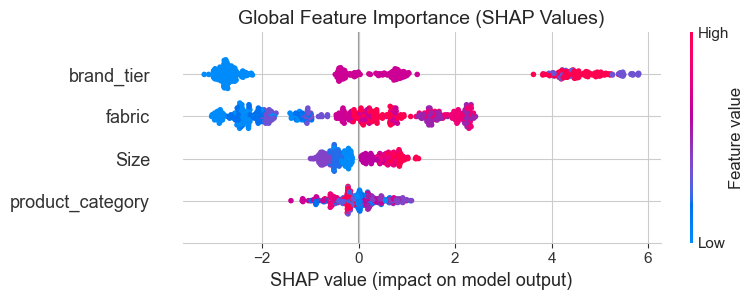

In [29]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Initialize SHAP explainer
explainer = shap.TreeExplainer(clf)  # <-- replace with your actual model

# Sample from test set
sample_idx = np.random.choice(X_test.index, size=min(500, len(X_test)), replace=False)
X_test_sample = X_test.loc[sample_idx]

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_sample)

# Clean feature names
feature_names = [col.replace('_encoded', '') for col in X_test_sample.columns]

# Plot
sns.set_style("whitegrid")
print("\nGlobal Feature Importance Plot:")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, show=False)
plt.title("Global Feature Importance (SHAP Values)", fontsize=14)
plt.tight_layout()
plt.show()



Dependence Plot for Brand Tier:


<Figure size 1000x600 with 0 Axes>

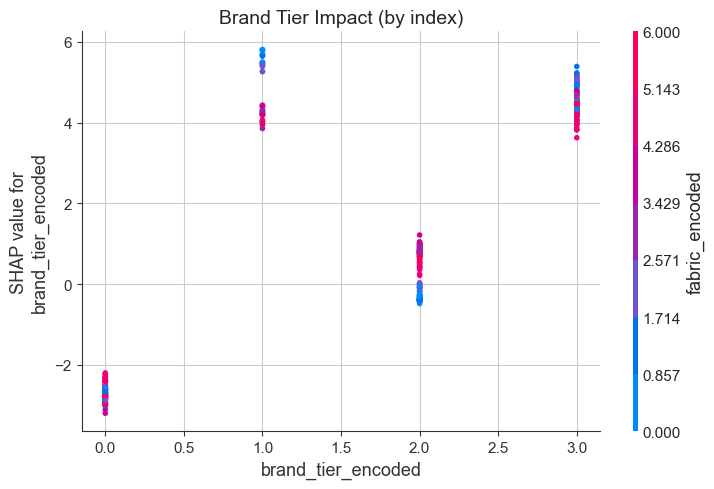

In [30]:
# Dependence Plot for Brand Tier
sns.set_style("whitegrid")
print("\nDependence Plot for Brand Tier:")
try:
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        'brand_tier_encoded',
        shap_values,
        X_test_sample,
        feature_names=feature_names,
        interaction_index=None,
        show=False
    )
    plt.title("Brand Tier Impact on Pricing", fontsize=14)
    plt.tight_layout()
    plt.show()
except Exception as e:
    brand_idx = list(X_test.columns).index('brand_tier_encoded')
    shap.dependence_plot(
        brand_idx,
        shap_values,
        X_test_sample,
        show=False
    )
    plt.title("Brand Tier Impact (by index)", fontsize=14)
    plt.tight_layout()
    plt.show()

In [31]:
import random
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Set style
sns.set_style("whitegrid")

# Generate and store 3 random indices
random_indices = random.sample(range(len(X_test_sample)), 3)
print(f"Selected observation indices: {random_indices}")

# Optional: Save to a variable for the next cell
%store random_indices

Selected observation indices: [442, 170, 483]
Stored 'random_indices' (list)


<Figure size 1200x300 with 0 Axes>

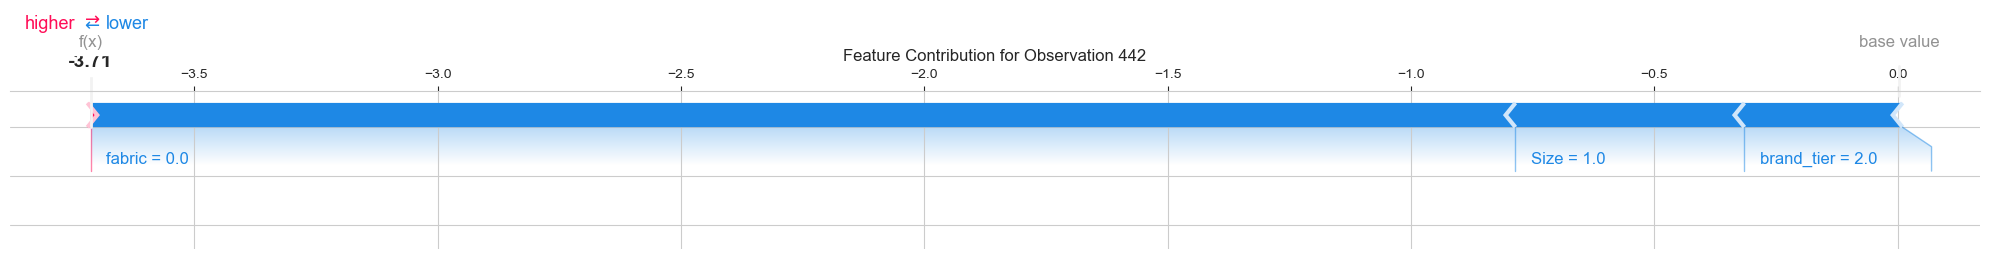

<Figure size 1200x300 with 0 Axes>

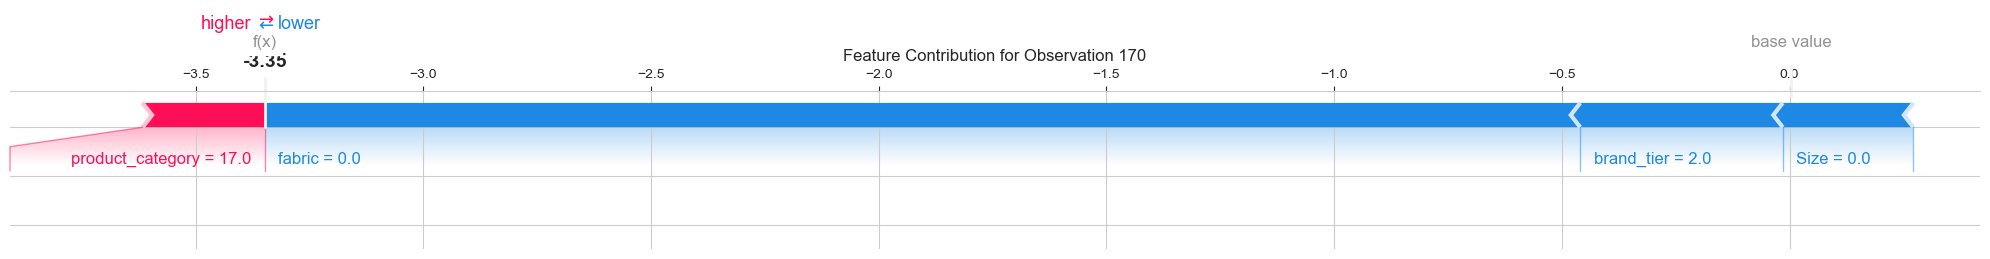

<Figure size 1200x300 with 0 Axes>

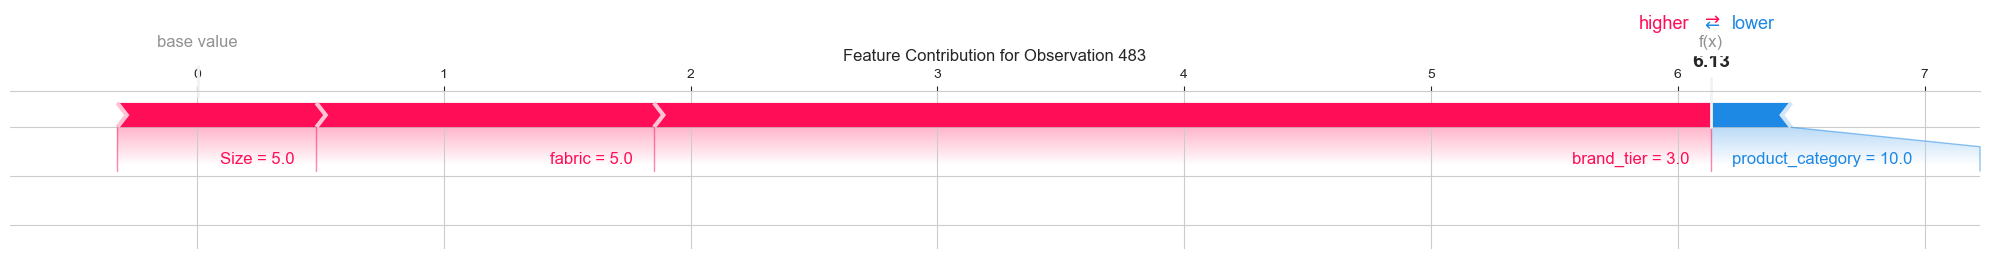

In [32]:
%store -r random_indices
for idx in random_indices:
    plt.figure(figsize=(12, 3))
    shap.force_plot(
        explainer.expected_value,
        shap_values[idx, :],
        X_test_sample.iloc[idx, :],
        feature_names=feature_names,
        matplotlib=True,
        show=False
    )
    plt.title(f"Feature Contribution for Observation {idx}", fontsize=12)
    plt.tight_layout()
    plt.show()

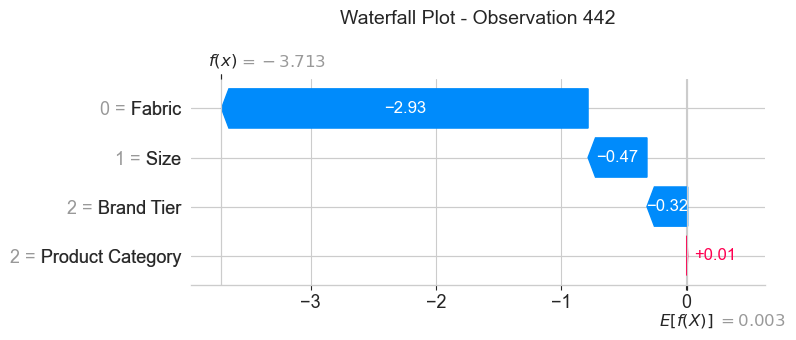

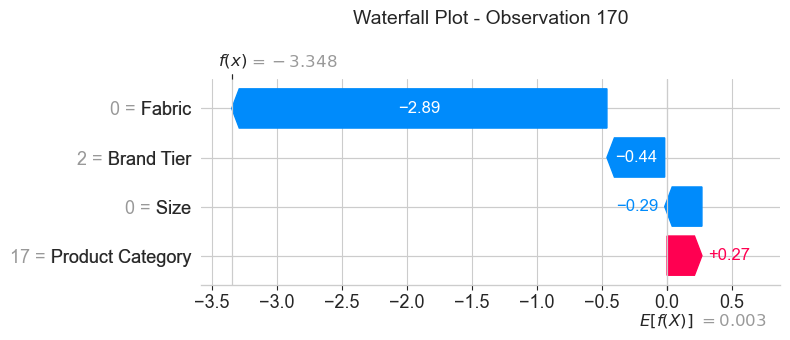

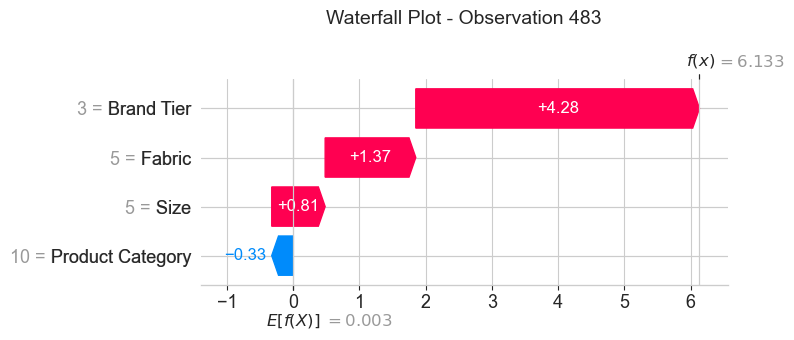

In [33]:
%store -r random_indices
# Generate waterfall plots
for idx in random_indices:
    plt.figure(figsize=(12, 6))
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_test_sample.iloc[idx],
            feature_names=[f.replace('_', ' ').title() for f in feature_names]
        ),
        max_display=8,
        show=False
    )
    plt.title(f"Waterfall Plot - Observation {idx}", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()